In [1]:
# importing the libraries

import torch
import torch.nn as nn

In [2]:
# Now we are building the Architecture for the downsampling

class DoubleConvo(nn.Module):

    def __init__(self,in_c,out_c): # The initial Architechuter for each covo block we take input and it gives the output
        super().__init__()
        self.convo = nn.Sequential( # How deos covo block does its thing like one after the other "Sequential"
            nn.Conv2d(in_c,out_c,kernel_size=3,padding = 1), # Each contains input gives an ouput and has a kernal of 3x3, padding = 1
            nn.ReLU(), # the we do the ReLu()

            nn.Conv2d(out_c,out_c, kernel_size=3,padding=1),
            nn.ReLU()
        )

    def forward(self,x):
        return self.convo(x) # Now each x which is one covo block we define we do the whole "self.covo(x)""

In [3]:
# Now implementing the attention skip connections

class Attention(nn.Module):
    def __init__(self,xa,ga,inter): # xa is the output of the convo block, ga for upsmaple and inter outuput we consider for the xa,ga
        super().__init__()

        self.xa = nn.Conv2d(xa,inter,kernel_size = 1) # xa is the input, inter is output
        self.ga = nn.Conv2d(ga,inter,kernel_size=1) #ga is input, inter is output

        self.psi = nn.Conv2d(inter,1,kernel_size=1) # we take the inter as input and we get 1 as output the height
        self.relu = nn.ReLU() # we take Relu
        self.sigmoid = nn.Sigmoid() # we take the sigmoid function here

    def forward(self, x, g): # this is to do the actual attention skip connection
        x1 = self.xa(x) #we define x over self.xa(x) for a give convo block
        g1 = self.ga(g) # same thing happens over self.ga(g) for a upsample

        psi = self.relu(x1+ g1) # we taking the relu for the xa+ga
        psi = self.sigmoid(self.psi(psi)) #then we converthing to a self.psi dim first and then we apply sigmoid for each elm in dim

        return x * psi     # get take in the x * psi here and then concate with the upsample to get our up convo bloacks



In [4]:
# Now building the whole Model

class AttenUnet(nn.Module):
    def __init__(self):
        super().__init__()
        # down

        self.down1 = DoubleConvo(1,64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConvo(64,128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConvo(128,256)
        self.pool3 = nn.MaxPool2d(2)

        # bottle nect

        self.bottleneck = DoubleConvo(256,512)

        # up

        self.u1 = nn.ConvTranspose2d(512,256,kernel_size=2, stride=2)
        self.att1 = Attention(256,256,128)
        self.convo1 = DoubleConvo(512,256)

        self.u2 = nn.ConvTranspose2d(256,128,kernel_size=2, stride=2)
        self.att2 = Attention(128,128,64)
        self.convo2 = DoubleConvo(256,128)

        self.u3 = nn.ConvTranspose2d(128,64,kernel_size=2, stride=2)
        self.att3 = Attention(64,64,32)
        self.convo3 = DoubleConvo(128,64)

        # final output

        self.out = nn.Conv2d(64,1, kernel_size = 1)

    def forward(self,x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        # bottle neck

        b = self.bottleneck(p3)

        # out

        u1 = self.u1(b)
        d3_attn = self.att1(d3,u1)
        u1 = torch.cat([u1,d3_attn],dim = 1)
        u1 = self.convo1(u1)

        u2 = self.u2(u1)
        d2_attn = self.att2(d2,u2)
        u2 = torch.cat([u2,d2_attn],dim= 1)
        u2 = self.convo2(u2)

        u3 = self.u3(u2)
        d1_attn = self.att3(d1,u3)
        u3 = torch.cat([u3,d1_attn],dim= 1)
        u3 = self.convo3(u3)


        return torch.sigmoid(self.out(u3))

In [5]:
!kaggle datasets download -d tschandl/isic2018-challenge-task1-data-segmentation

Dataset URL: https://www.kaggle.com/datasets/tschandl/isic2018-challenge-task1-data-segmentation
License(s): CC0-1.0
100% 12.9G/12.9G [10:09<00:00, 22.7MB/s]



In [6]:
!unzip -q isic2018-challenge-task1-data-segmentation.zip

In [34]:
from torch.utils.data import Dataset
import os
from PIL import Image
import numpy as np
import torch

class ISICDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir

        self.images = []
        for f in os.listdir(img_dir):
            if f.endswith(".jpg"):
                mask_name = f.replace(".jpg", "_segmentation.png")
                mask_path = os.path.join(mask_dir, mask_name)

                if os.path.exists(mask_path):
                    self.images.append(f)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(
            self.mask_dir,
            img_name.replace(".jpg", "_segmentation.png")
        )

        image = Image.open(img_path).convert("L").resize((256,256))
        mask = Image.open(mask_path).convert("L").resize((256,256))

        image = np.array(image) / 255.0
        mask = np.array(mask) / 255.0

        mask = (mask > 0).astype(float)

        image = torch.tensor(image).unsqueeze(0).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [8]:
train_dataset = ISICDataset(
    "/content/ISIC2018_Task1-2_Training_Input",
    "/content/ISIC2018_Task1_Training_GroundTruth"
)

In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttenUnet().to(device)

In [11]:
import torch.nn as nn

bce = nn.BCELoss()

def dice_loss(pred, target):
    smooth = 1e-6
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def loss_fn(pred, target):
    return bce(pred, target) + dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

In [13]:
for epoch in range(10):

    model.train()
    total_loss = 0

    for img, mask in train_loader:

        img = img.to(device)
        mask = mask.to(device)

        pred = model(img)

        loss = loss_fn(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch}, Loss: {avg_loss:.4f}")

Epoch 0, Loss: 1.1061
Epoch 1, Loss: 0.8704
Epoch 2, Loss: 0.6584
Epoch 3, Loss: 0.5637
Epoch 4, Loss: 0.5327
Epoch 5, Loss: 0.5048
Epoch 6, Loss: 0.4734
Epoch 7, Loss: 0.4637
Epoch 8, Loss: 0.4551
Epoch 9, Loss: 0.4404


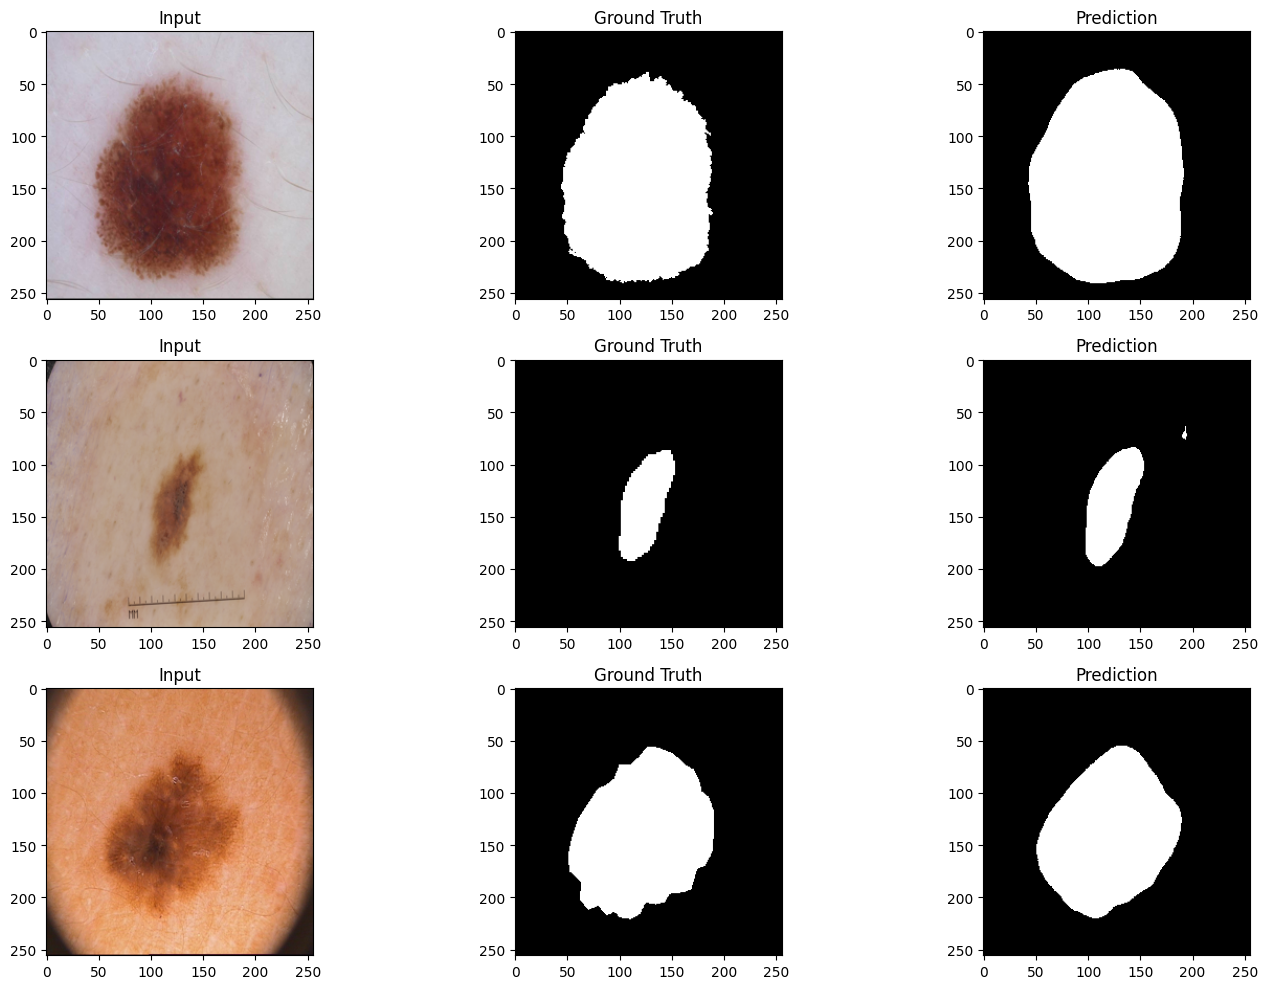

In [24]:
import matplotlib.pyplot as plt
from PIL import Image
import os

model.eval()

indices = [75, 167, 100]

plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):

    img_name = train_dataset.images[idx]

    img_path = os.path.join(train_dataset.img_dir, img_name)
    mask_path = os.path.join(
        train_dataset.mask_dir,
        img_name.replace(".jpg", "_segmentation.png")
    )

    color_img = Image.open(img_path).resize((256,256))

    img, mask = train_dataset[idx]

    img_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_tensor)

    pred = pred.cpu().squeeze().numpy()
    pred = (pred > 0.5).astype(float)
    mask = mask.squeeze().numpy()

    plt.subplot(3, 3, i*3 + 1)
    plt.title("Input")
    plt.imshow(color_img)

    plt.subplot(3, 3, i*3 + 2)
    plt.title("Ground Truth")
    plt.imshow(mask, cmap='gray')

    plt.subplot(3, 3, i*3 + 3)
    plt.title("Prediction")
    plt.imshow(pred, cmap='gray')

plt.tight_layout()
plt.show()

## Validation

In [36]:
from torch.utils.data import DataLoader, random_split
import torch

full_dataset = ISICDataset(
    "/content/ISIC2018_Task1-2_Training_Input",
    "/content/ISIC2018_Task1_Training_GroundTruth"
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

_, val_dataset = random_split(full_dataset, [train_size, val_size])

val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

model.eval()

dice_total = 0
iou_total = 0

with torch.no_grad():
    for img, mask in val_loader:
        img = img.to(device)
        mask = mask.to(device)

        pred = model(img)
        pred = (pred > 0.5).float()

        intersection = (pred * mask).sum()
        dice = (2 * intersection + 1e-6) / (pred.sum() + mask.sum() + 1e-6)

        union = pred.sum() + mask.sum() - intersection
        iou = (intersection + 1e-6) / (union + 1e-6)

        dice_total += dice.item()
        iou_total += iou.item()

avg_dice = dice_total / len(val_loader)
avg_iou = iou_total / len(val_loader)

print("Validation Dice:", avg_dice)
print("Validation IoU:", avg_iou)

Validation Dice: 0.8268135996965261
Validation IoU: 0.7093960413566003


## Validation Visualization

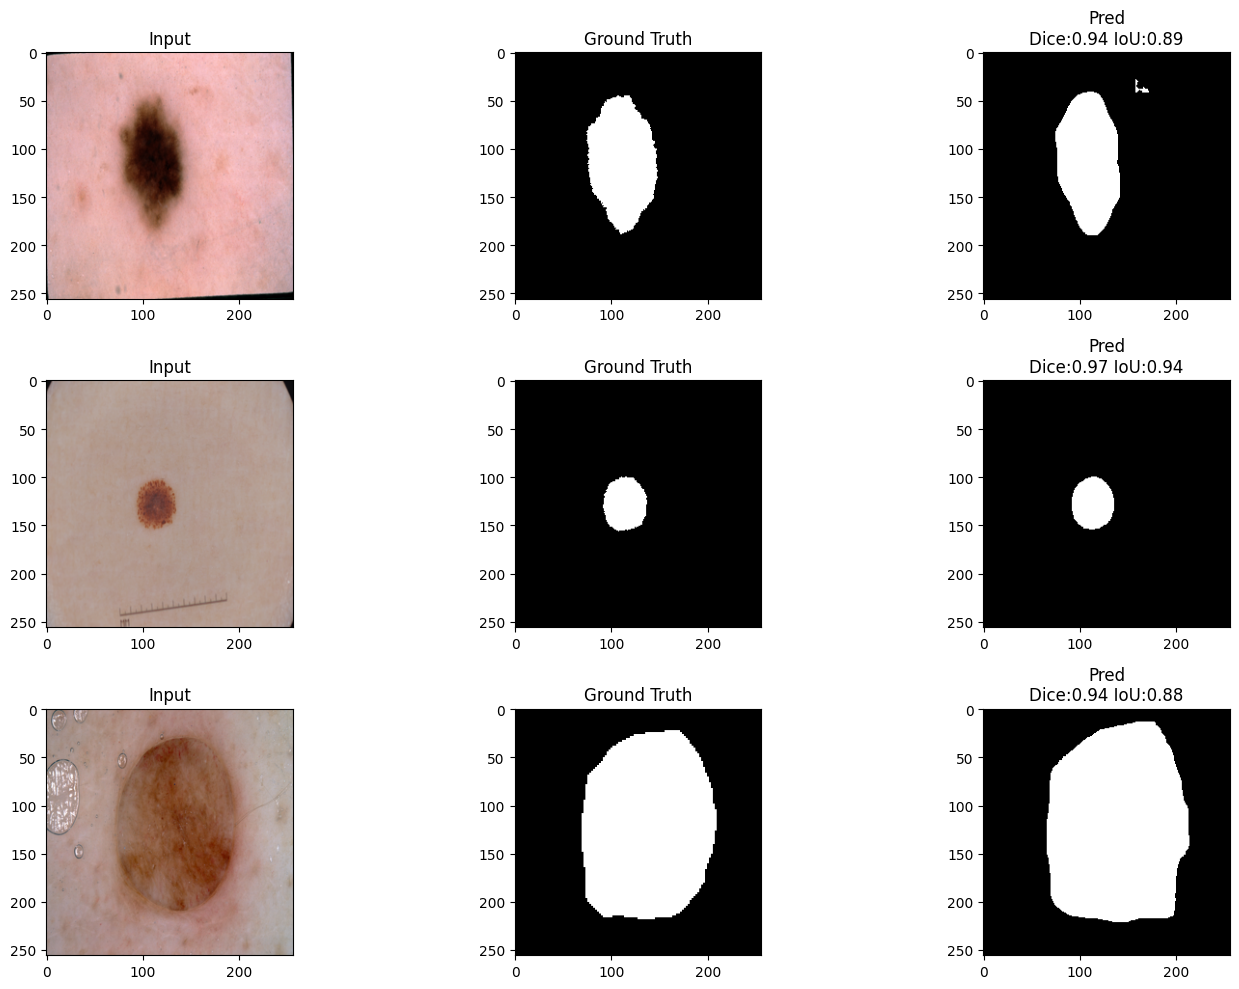

In [47]:
import matplotlib.pyplot as plt
from PIL import Image
import os

model.eval()

indices = [35, 10, 20]

plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):

    real_idx = val_dataset.indices[idx]
    img_name = full_dataset.images[real_idx]

    img_path = os.path.join(full_dataset.img_dir, img_name)

    color_img = Image.open(img_path).resize((256,256))

    img, mask = val_dataset[idx]

    img_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_tensor)

    pred = (pred > 0.5).float().cpu().squeeze().numpy()
    mask = mask.squeeze().numpy()

    intersection = (pred * mask).sum()
    dice = (2 * intersection + 1e-6) / (pred.sum() + mask.sum() + 1e-6)

    union = pred.sum() + mask.sum() - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)

    plt.subplot(3, 3, i*3 + 1)
    plt.title("Input")
    plt.imshow(color_img)

    plt.subplot(3, 3, i*3 + 2)
    plt.title("Ground Truth")
    plt.imshow(mask, cmap='gray')

    plt.subplot(3, 3, i*3 + 3)
    plt.title(f"Pred\nDice:{dice:.2f} IoU:{iou:.2f}")
    plt.imshow(pred, cmap='gray')

plt.tight_layout()
plt.show()

## Testing

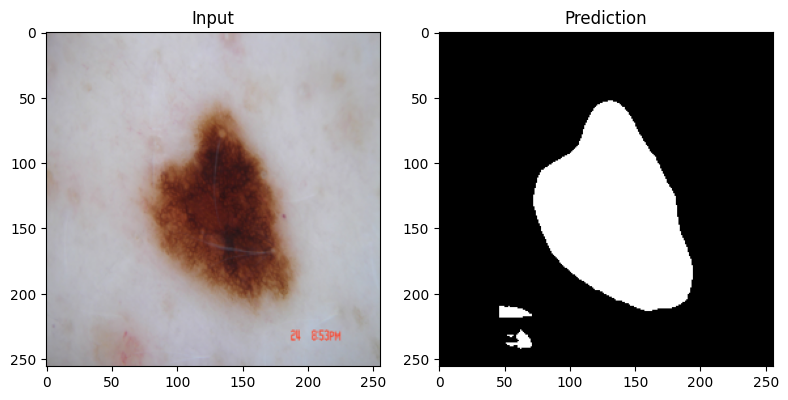

In [55]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np
import torch
import random

model.eval()

test_dir = "/content/ISIC2018_Task1-2_Test_Input"

f = random.choice([x for x in os.listdir(test_dir) if x.endswith(".jpg")])

img_path = os.path.join(test_dir, f)

color_img = Image.open(img_path).resize((256,256))
gray_img = Image.open(img_path).convert("L").resize((256,256))

img_np = np.array(gray_img) / 255.0
img_tensor = torch.tensor(img_np).unsqueeze(0).unsqueeze(0).float().to(device)

with torch.no_grad():
    pred = model(img_tensor)

pred = (pred > 0.5).float().cpu().squeeze().numpy()

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Input")
plt.imshow(color_img)

plt.subplot(1,2,2)
plt.title("Prediction")
plt.imshow(pred, cmap='gray')

plt.tight_layout()
plt.show()

## Saving the Attention Unet Model

In [56]:
best_dice = 0

for epoch in range(10):

    # training

    # validation → gives avg_dice

    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), "best_model.pth")

In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttenUnet().to(device)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

AttenUnet(
  (down1): DoubleConvo(
    (convo): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConvo(
    (convo): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down3): DoubleConvo(
    (convo): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilatio

In [59]:
with torch.no_grad():
    pred = model(img_tensor)